# Applied Network Science — Practice 00
**Programming expectations**
*by sandorjuhasz*

---

**Structure**
- 01 Loops
- 02 Writing a simple function
- 03 Lists
- 04 Dictionaries
- 05 pandas -- reading a table
- 06 Boolean filtering
- 07 Loop over an id, then the pandas way (aggregation)
- 08 Plotting -- scatter
- 09 Plotting -- histogram
- 10 Side-by-side plots

---

This notebook is **not about networks**. It's a checklist: the level of plain Python and pandas
we assume you're comfortable with *before* the first practice session. Week 01 starts straight in
with dicts, lambdas, `pd.read_csv`, and matplotlib -- no ramp-up -- so if any section below looks
unfamiliar, work through it before class.

Nothing here uses `networkx` -- that starts in Practice 01. See the course README for environment
setup (`ans-env`, `requirements.txt`) if you haven't installed anything yet.

In [1]:
# packages we will use
import pandas as pd
import matplotlib.pyplot as plt

---

### 01 Loops

The workhorse of everyday Python -- doing something once per item in a list.

In [2]:
products = ["Notebook", "Backpack", "Headphones", "Water Bottle", "Desk Lamp"]

# a plain for loop
for product in products:
    print(product, "--", len(product), "characters")

Notebook -- 8 characters
Backpack -- 8 characters
Headphones -- 10 characters
Water Bottle -- 12 characters
Desk Lamp -- 9 characters


The same thing, written as a list comprehension -- shorter, and something you'll see a lot
starting week 01.

In [3]:
name_lengths = [len(product) for product in products]
name_lengths

[8, 8, 10, 12, 9]

---

### 02 Writing a simple function

Wrap repeated logic in a function once you've written it more than once.

In [4]:
def shout(text):
    """Return text in upper case, with an exclamation mark."""
    return text.upper() + "!"

shout("networks are everywhere")

'NETWORKS ARE EVERYWHERE!'

In [5]:
# calling it inside a loop, same as section 01
for product in products:
    print(shout(product))

NOTEBOOK!
BACKPACK!
HEADPHONES!
WATER BOTTLE!
DESK LAMP!


---

### 03 Lists

Building, indexing, slicing, and sorting a list.

In [6]:
prices = [3, 45, 80, 12, 25]  # same catalog/order as toy_sales.csv's products

print("first:", prices[0])
print("last:", prices[-1])
print("first three:", prices[:3])

first: 3
last: 25
first three: [3, 45, 80]


In [7]:
# sorted() returns a new sorted list, leaving the original untouched
cheapest_first = sorted(prices)
cheapest_first

[3, 12, 25, 45, 80]

In [8]:
# sort descending with reverse=True
priciest_first = sorted(prices, reverse=True)
priciest_first

[80, 45, 25, 12, 3]

---

### 04 Dictionaries

Key-value lookups -- and how to sort one by its values, which is something we'll do constantly
starting week 01 (e.g. sorting nodes by degree).

In [9]:
price_by_product = dict(zip(products, prices))
price_by_product

{'Notebook': 3,
 'Backpack': 45,
 'Headphones': 80,
 'Water Bottle': 12,
 'Desk Lamp': 25}

In [10]:
print("price of a Backpack:", price_by_product["Backpack"])

# a dict comprehension -- same idea as the list comprehension in section 01
discounted = {
    product: price * 0.9 for product, price in price_by_product.items()
}
discounted

price of a Backpack: 45


{'Notebook': 2.7,
 'Backpack': 40.5,
 'Headphones': 72.0,
 'Water Bottle': 10.8,
 'Desk Lamp': 22.5}

Sorting a dict by value: convert to `(key, value)` pairs with `.items()`, sort those with a
`lambda` that picks out the value, then rebuild a dict. This exact pattern is how we'll sort nodes
by degree/centrality from week 01 onward.

In [11]:
# cheapest product first
dict(sorted(price_by_product.items(), key=lambda x: x[1]))

{'Notebook': 3,
 'Water Bottle': 12,
 'Desk Lamp': 25,
 'Backpack': 45,
 'Headphones': 80}

In [12]:
# most expensive product first -- negate the value, or pass reverse=True
dict(sorted(price_by_product.items(), key=lambda x: x[1], reverse=True))

{'Headphones': 80,
 'Backpack': 45,
 'Desk Lamp': 25,
 'Water Bottle': 12,
 'Notebook': 3}

---

### 05 pandas -- reading a table

**Data:** `toy_sales.csv` -- a fabricated retail-order table (not a real dataset, see
`practice_data/README.md`). Used only to demonstrate table mechanics before real data shows up in
week 01.

In [13]:
sales = pd.read_csv("practice_data/toy_sales.csv")
sales.head()

,order_id,customer_id,product,region,quantity,amount
0,O001,C04,Notebook,North,1,3
1,O002,C07,Backpack,East,1,45
2,O003,C04,Notebook,North,5,15
3,O004,C07,Notebook,East,5,15
4,O005,C02,Water Bottle,South,5,60


In [14]:
print("rows:", len(sales))
print("columns:", list(sales.columns))

rows: 36
columns: ['order_id', 'customer_id', 'product', 'region', 'quantity', 'amount']


---

### 06 Boolean filtering

Selecting rows of a DataFrame with a condition, instead of a loop -- the pandas equivalent of
filtering a list.

In [15]:
# orders worth more than 40
big_orders = sales[sales["amount"] > 40]
big_orders.head()

,order_id,customer_id,product,region,quantity,amount
1,O002,C07,Backpack,East,1,45
4,O005,C02,Water Bottle,South,5,60
5,O006,C01,Headphones,East,5,400
7,O008,C01,Headphones,East,2,160
8,O009,C05,Backpack,North,2,90


In [16]:
# combine conditions with & (and) / | (or) -- parentheses matter here
west_notebooks = sales[
    (sales["region"] == "West") & (sales["product"] == "Notebook")
]
west_notebooks

,order_id,customer_id,product,region,quantity,amount
10,O011,C03,Notebook,West,5,15


---

### 07 Loop over an id, then the pandas way

First, the manual version: loop over each customer id and add up their spending by hand.

In [17]:
total_by_customer = {}

for customer_id in sales["customer_id"].unique():
    customer_orders = sales[sales["customer_id"] == customer_id]
    # int(...) here keeps the output plain (no np.int64(...) wrapper)
    total_by_customer[customer_id] = int(customer_orders["amount"].sum())

dict(sorted(total_by_customer.items(), key=lambda x: x[1], reverse=True))

{'C02': 1397,
 'C01': 695,
 'C05': 649,
 'C08': 549,
 'C07': 346,
 'C04': 292,
 'C03': 145,
 'C06': 75}

That's correct, but it's a lot of code for "sum amount, grouped by customer." This is what
we'll actually use in class: `.groupby()` does exactly the same loop-filter-sum internally, in one
line.

In [18]:
sales.groupby("customer_id")["amount"].sum().sort_values(ascending=False)

customer_id
C02    1397
C01     695
C05     649
C08     549
C07     346
C04     292
C03     145
C06      75
Name: amount, dtype: int64

`.agg()` generalizes this to several summaries at once.

In [19]:
sales.groupby("customer_id")["amount"].agg(["sum", "mean", "count"])

,sum,mean,count
customer_id,,,
C01,695,231.666667,3
C02,1397,174.625000,8
C03,145,48.333333,3
C04,292,58.400000,5
C05,649,129.800000,5
C06,75,75.000000,1
C07,346,69.200000,5
C08,549,91.500000,6


---

### 08 Plotting -- scatter

Does buying more units (`quantity`) mean spending more (`amount`)?

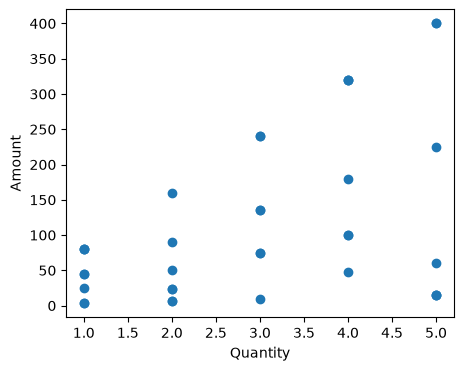

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(sales["quantity"], sales["amount"])
ax.set_xlabel("Quantity")
ax.set_ylabel("Amount")
plt.show()

---

### 09 Plotting -- histogram

How is order value distributed across all orders?

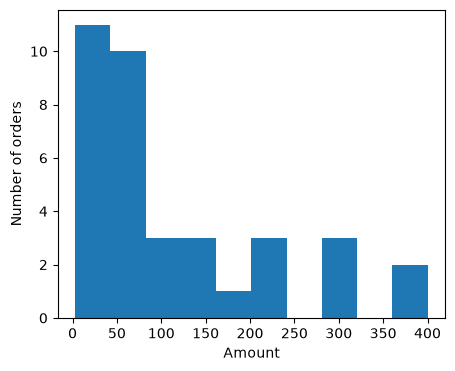

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(sales["amount"], bins=10)
ax.set_xlabel("Amount")
ax.set_ylabel("Number of orders")
plt.show()

---

### 10 Side-by-side plots

The scatter and the histogram above, drawn next to each other in one figure -- the pattern
we'll use whenever we want to compare two views of the same data.

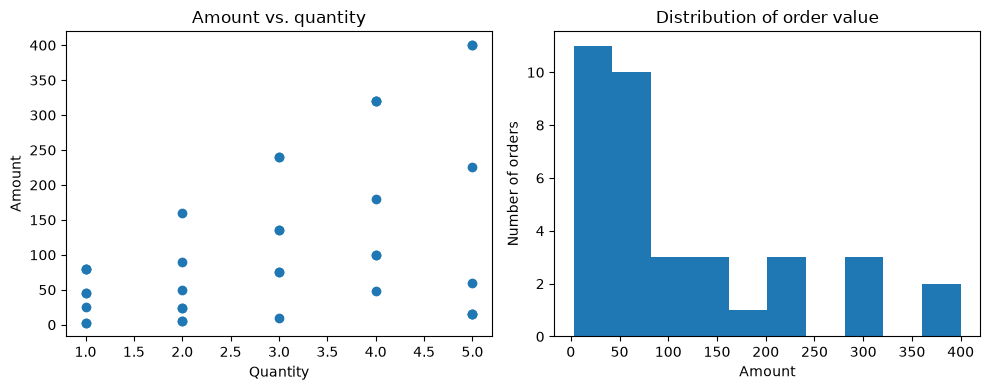

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(sales["quantity"], sales["amount"])
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Amount")
axes[0].set_title("Amount vs. quantity")

axes[1].hist(sales["amount"], bins=10)
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("Number of orders")
axes[1].set_title("Distribution of order value")

plt.tight_layout()
plt.show()

---

If everything above ran cleanly and made sense, you're ready for Practice 01. If not, this is a
good time to brush up -- we build directly on all ten of these from the very first class.